# Vehicle Fuel Efficiency Analysis

## Objective
This project explores the factors that influence vehicle fuel efficiency using the Auto MPG dataset. The analysis examines how characteristics such as weight, horsepower, cylinders, and model year affect miles per gallon (MPG).

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")

## Load Dataset
The dataset is loaded into Python for inspection and analysis.

In [26]:
mpg = sns.load_dataset("mpg")
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Dataset Overview

The dataset contains information about vehicles, including engine characteristics, weight, acceleration, and fuel efficiency (MPG).

### Key variables
- `mpg`: miles per gallon
- `cylinders`: number of engine cylinders
- `displacement`: engine size
- `horsepower`: engine horsepower
- `weight`: vehicle weight
- `acceleration`: acceleration performance
- `model_year`: vehicle model year
- `origin`: country/region of origin

In [27]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [28]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## Data Cleaning

The dataset was checked for missing values and cleaned to improve analysis accuracy. Missing observations were removed before building the visualizations.

In [29]:
mpg.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [30]:
mpg_clean = mpg.dropna()
mpg_clean.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [31]:
mpg_clean.shape

(392, 9)

## Visualization 1: Vehicle Weight vs Fuel Efficiency

This scatterplot shows the relationship between vehicle weight and miles per gallon (MPG). Each point represents a vehicle in the dataset.

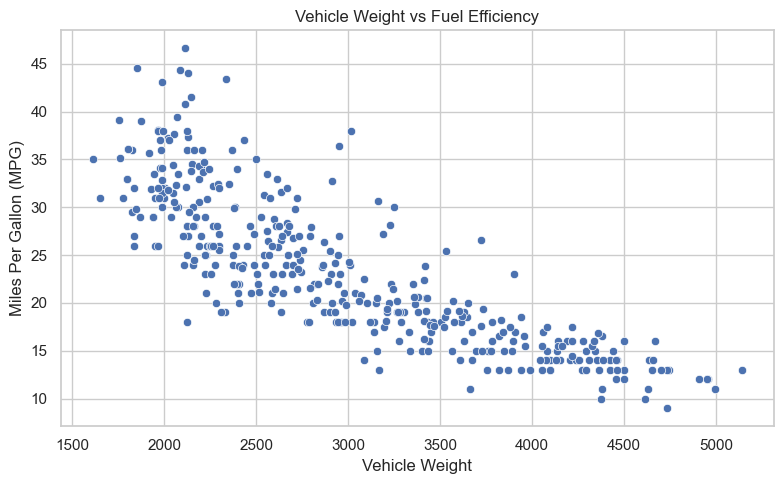

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=mpg_clean, x="weight", y="mpg")
plt.title("Vehicle Weight vs Fuel Efficiency")
plt.xlabel("Vehicle Weight")
plt.ylabel("Miles Per Gallon (MPG)")
plt.tight_layout()
plt.show()

### Analysis
The scatterplot shows a clear negative relationship between vehicle weight and fuel efficiency. Heavier vehicles generally achieve lower MPG, suggesting that weight is a major factor affecting fuel consumption.

## Visualization 2: Average Fuel Economy by Country of Origin

This table summarizes average fuel efficiency (MPG) across vehicles from different regions of origin. Grouping the data by origin helps highlight how fuel economy varies across countries.

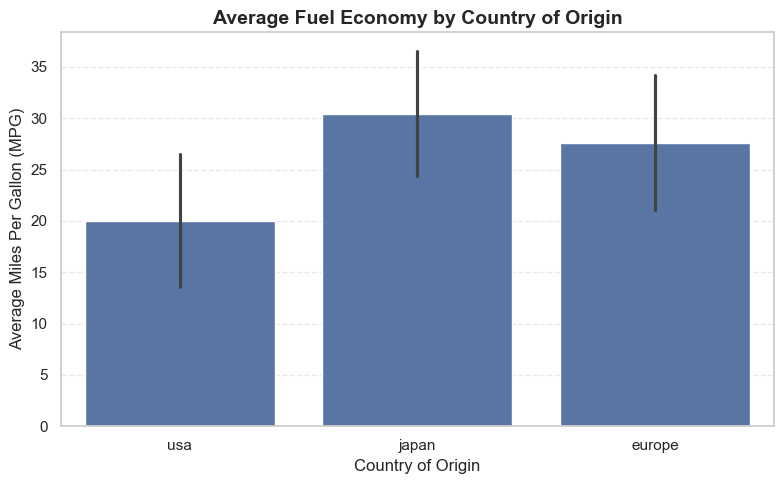

In [42]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=mpg_clean,
    x="origin",
    y="mpg",
    estimator="mean",
    errorbar="sd"
)

plt.title("Average Fuel Economy by Country of Origin", fontsize=14, weight="bold")
plt.xlabel("Country of Origin")
plt.ylabel("Average Miles Per Gallon (MPG)")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

### Analysis

The bar chart compares the average fuel efficiency of vehicles based on their country of origin. Vehicles from Japan tend to have the highest average MPG, while vehicles from the USA generally show lower fuel efficiency. European vehicles fall between the two. 

This pattern may reflect differences in vehicle design and manufacturing priorities, where Japanese manufacturers historically emphasized smaller, more fuel-efficient vehicles, while American vehicles tended to prioritize larger engines and heavier designs.

## Visualization 3: Fuel Economy Trends Over Time

This visualization examines how vehicle fuel efficiency has changed across different model years. By calculating the average MPG for each model year, we can observe trends in fuel economy improvements over time.

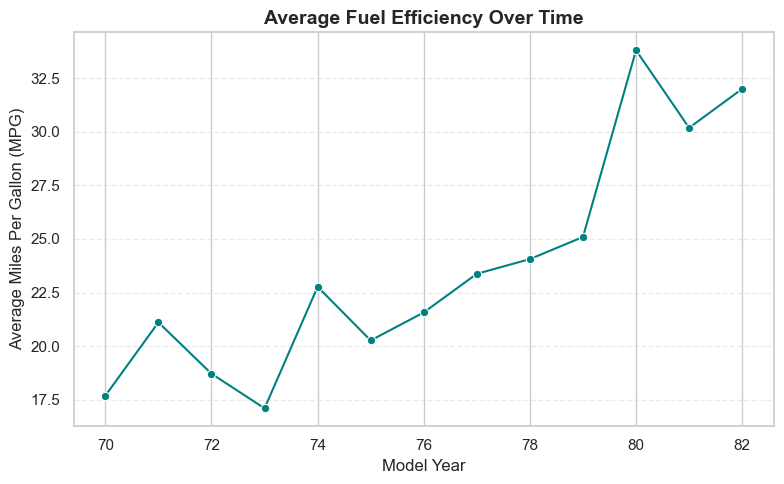

In [39]:
sns.set(style="whitegrid")

avg_mpg_year = mpg_clean.groupby("model_year")["mpg"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=avg_mpg_year,
    x="model_year",
    y="mpg",
    marker="o",
    color="teal"
)

plt.title("Average Fuel Efficiency Over Time", fontsize=14, weight="bold")
plt.xlabel("Model Year")
plt.ylabel("Average Miles Per Gallon (MPG)")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

### Analysis

The line chart shows a clear upward trend in average fuel efficiency over time. Vehicles produced in later model years generally achieve higher MPG compared to earlier vehicles. This suggests that improvements in automotive engineering, fuel efficiency standards, and technological advancements contributed to better fuel economy in newer vehicles.

## Visualization 4: Vehicle Weight vs Fuel Economy

This scatterplot examines the relationship between vehicle weight and fuel efficiency (MPG). Each point represents a vehicle in the dataset, allowing us to observe how fuel economy changes as vehicle weight increases.

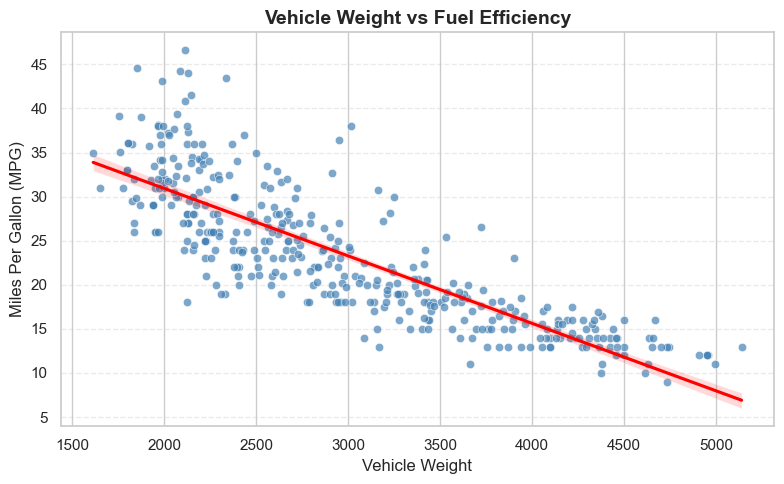

In [35]:
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=mpg_clean,
    x="weight",
    y="mpg",
    alpha=0.7,
    color="steelblue"
)

sns.regplot(
    data=mpg_clean,
    x="weight",
    y="mpg",
    scatter=False,
    color="red"
)

plt.title("Vehicle Weight vs Fuel Efficiency", fontsize=14, weight="bold")
plt.xlabel("Vehicle Weight")
plt.ylabel("Miles Per Gallon (MPG)")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

### Analysis

The scatterplot shows a clear negative relationship between vehicle weight and fuel efficiency. As vehicle weight increases, miles per gallon (MPG) tends to decrease. This suggests that heavier vehicles require more fuel to operate, resulting in lower fuel efficiency.

## Visualization 5: Acceleration vs Fuel Economy

This scatterplot explores the relationship between vehicle acceleration and fuel efficiency. Each point represents a vehicle in the dataset, allowing us to observe whether faster acceleration is associated with higher or lower fuel economy.

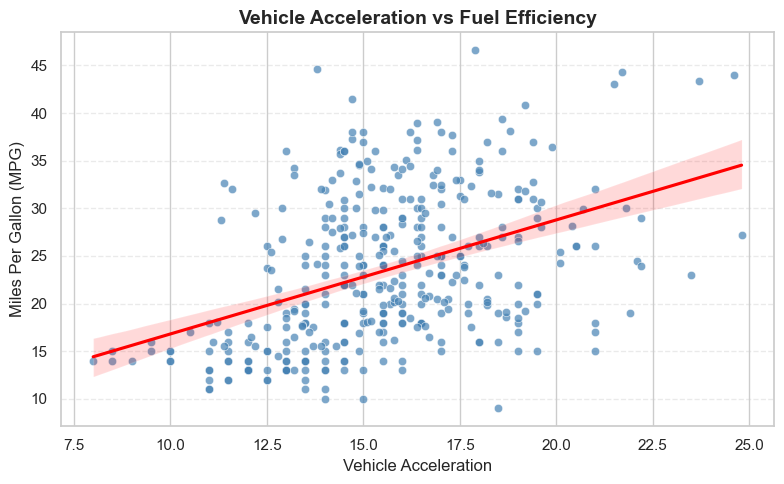

In [40]:
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=mpg_clean,
    x="acceleration",
    y="mpg",
    alpha=0.7,
    color="steelblue"
)

sns.regplot(
    data=mpg_clean,
    x="acceleration",
    y="mpg",
    scatter=False,
    color="red"
)

plt.title("Vehicle Acceleration vs Fuel Efficiency", fontsize=14, weight="bold")
plt.xlabel("Vehicle Acceleration")
plt.ylabel("Miles Per Gallon (MPG)")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

### Analysis

The scatterplot suggests a weaker relationship between acceleration and fuel efficiency compared to other variables such as weight or horsepower. While some vehicles with higher acceleration appear to achieve moderate MPG, acceleration alone does not appear to be a strong predictor of fuel economy.

## Key Insights

- **Vehicle weight shows a strong negative relationship with MPG.** Heavier vehicles generally achieve lower fuel efficiency.

- **Fuel efficiency improves across model years.** Later vehicles tend to achieve higher average MPG, reflecting advancements in automotive technology.

- **Engine and vehicle design factors strongly influence MPG.** Characteristics such as weight, horsepower, and cylinder count appear to play a major role in fuel consumption.

- **Acceleration shows a weaker relationship with fuel economy.** Compared to other variables, acceleration does not strongly predict MPG.

- **Regional differences exist in fuel efficiency.** Japanese vehicles tend to have higher average MPG, likely due to smaller vehicle sizes and more fuel-efficient designs.

## Conclusion

This analysis explored the key factors influencing vehicle fuel efficiency using the Auto MPG dataset. The results show that vehicle weight has a strong negative relationship with MPG, indicating that heavier vehicles tend to consume more fuel.

Fuel efficiency also improves over time, suggesting technological advancements in automotive engineering and increased emphasis on fuel efficiency standards.

While variables such as acceleration show weaker relationships with MPG, overall vehicle design characteristics play an important role in determining fuel economy.